In [1]:
import numpy as np
import matplotlib.pyplot as plt
import io
import os
from scipy.optimize import curve_fit
from scipy.stats import norm
from PythonAnalysis import *

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 200
#plt.style.use(['science', 'no-latex', 'ieee'])
#import matplotlib
#print(matplotlib.get_backend())

In [ ]:
N_bootstrap=1000
N_k=6
UndulationSpectrum(VFF=0,EPS=0,N_k=N_k,Simulation="OnlyVectorField",FrameTension="IsotropicFrameTension",
                   InitialConfiguration="FromFlat",plot_func="q",i1=1,fit_func=False,N_bootstrap=N_bootstrap)

FileNotFoundError: [Errno 2] No such file or directory: 'IsotropicFrameTension/OnlyVectorField/FromFlat/EPS0/StaticUndulationSpectrum/LSFT6.txt'

In [ ]:
UndulationSpectrum(VFF=0,EPS=0,N_k=N_k,InitialConfiguration="FromFlat")

TypeError: AnisotropicUndulationSpectrum() missing 2 required positional arguments: 'plot_func' and 'N_bootstrap'

In [ ]:
UndulationSpectrum(VFF=5,EPS=5,N_k=N_k)

TypeError: AnisotropicUndulationSpectrum() missing 2 required positional arguments: 'InitialConfiguration' and 'outdir'

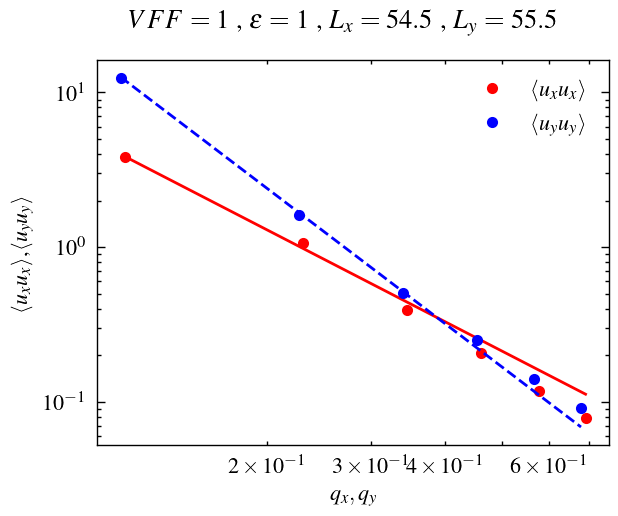

In [ ]:
UndulationSpectrum(VFF=1,EPS=1,N_k=N_k)

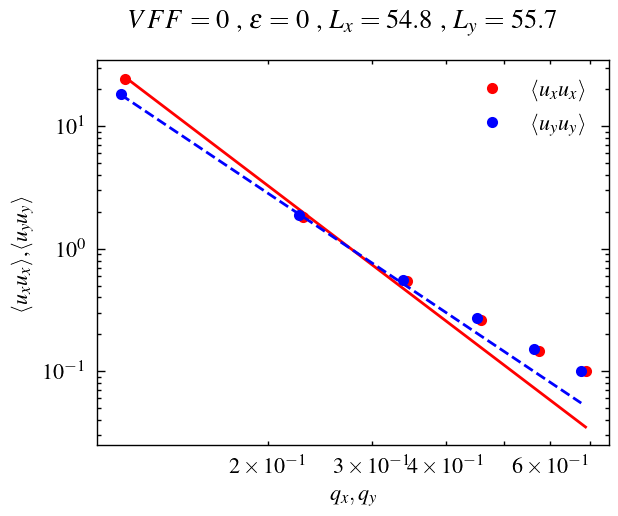

In [ ]:
UndulationSpectrum(VFF=0,EPS=0,N_k=N_k)

UndulationSpectrum(VFF=0.1, EPS=0.1, N_k=5)

In [ ]:
FTMethod = "LSFT"
fontsize = 15
kappa = 20

col_labels = [
    r"$n \pm \sigma$",
    r"$n_x \pm \sigma_x$",
    r"$n_y \pm \sigma_y$",
    r"$\kappa$",
    r"$\kappa_{\parallel}$",
    r"$\kappa_{\perp}$",
    r"$\epsilon$",
    r"$VFF$",
    r"$\xi$",
    r"$N_k$",
]

In [ ]:
Simulation = "OnlyVectorField"
EPS_list = [0, 1,5]
N_k_list = (3, 5, 8)
datasets = (('q', '<u u>'),('q_x', '<u_x u_x>'),('q_y', '<u_y u_y>'))
N=100000


table_data = []
for EPS in EPS_list:
    VFF = EPS
    for N_k in N_k_list:
        results = {}
        for dataset in datasets:
            file = f"AnisotropicFrameTension/OnlyVectorField/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/LSFT{N_k}.txt"
            data = load_boxsize_fourier_file(file)[dataset]
            i1 = 1
            mean, err = bootstrap(data[i1:, :], N=N)
            results[dataset] = (mean, err)

        mean_q, err_q = results[('q', '<u u>')]
        mean_x, err_x = results[('q_x', '<u_x u_x>')]
        mean_y, err_y = results[('q_y', '<u_y u_y>')]

        table_data.append([
            rf"${mean_q[1]:.2f} \pm {err_q[1]:.2f}$",
            rf"${mean_x[1]:.2f} \pm {err_x[1]:.2f}$",
            rf"${mean_y[1]:.2f} \pm {err_y[1]:.2f}$",
            rf"${kappa}$",
            rf"$0$",
            rf"$0$",
            rf"${EPS}$",
            rf"${VFF}$",
            rf"$0$",
            rf"{N_k}",
        ])

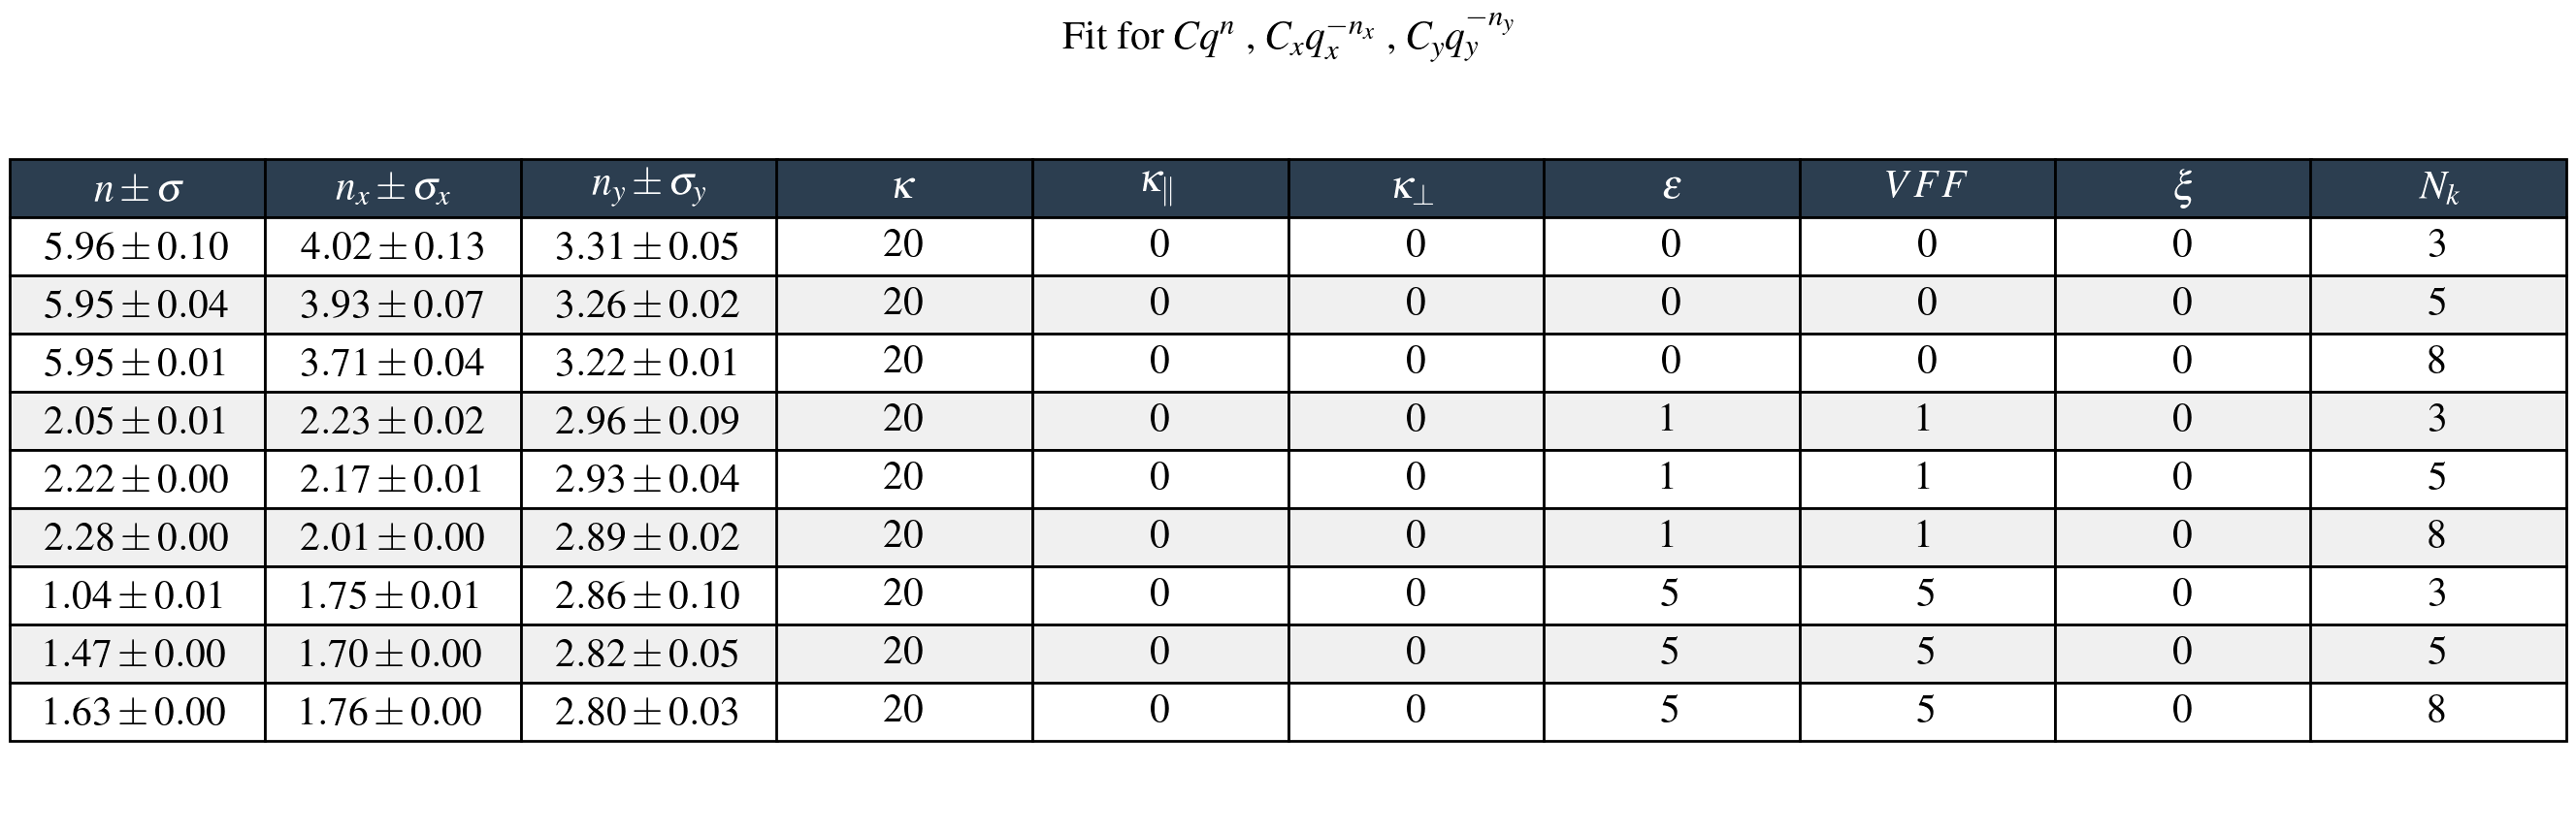

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(fontsize)
table.scale(1.7, 1.8)
# Style header row
for col_idx in range(len(col_labels)):
    table[0, col_idx].set_facecolor("#2c3e50")
    table[0, col_idx].set_text_props(color="white", fontweight="bold")

# Alternating row shading
for row_idx in range(1, len(table_data) + 1):
    color = "#f0f0f0be" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(col_labels)):
        table[row_idx, col_idx].set_facecolor(color)

plt.title(rf"Fit for $Cq^n$ , $C_xq_x^{{-n_x}}$ , $C_yq_y^{{-n_y}}$", 
          fontsize=fontsize, pad=10)

outdir = f"Plots/AnisotropicUndulationSpectrum/OnlyVectorField"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/UndulationTable.pdf", bbox_inches='tight')
#plt.savefig("bootstrap_table.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
adfds

In [2]:
def load_boxsize_fourier_file(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    # --- parse metadata ---
    Lx, Ly, Lz = map(float, lines[2].split())
    N_q_unique, N_qx_unique, N_qy_unique, N_k, FTMethod = lines[5].split()
    N_q_unique, N_qx_unique, N_qy_unique, N_k = (
        int(N_q_unique), int(N_qx_unique), int(N_qy_unique), int(N_k)
    )

    def is_header(line):
        return '<' in line and '>' in line and 'rep:' in line

    data = {}
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if is_header(line):
            prefix = line.split('<', 1)[0].strip()          # 'q', 'q_x', 'q_y', ...
            inner = "<" + " ".join(line.split('<', 1)[1].split('>', 1)[0].split()) + ">"
            name = (prefix,inner)
            #print(name)
            # collect lines until the next header or EOF
            j = i + 1
            block_lines = []
            while j < len(lines) and not is_header(lines[j].strip()) and lines[j].strip() != '':
                block_lines.append(lines[j])
                j += 1

            arr = np.loadtxt(io.StringIO(''.join(block_lines)))
            data[name] = arr
            i = j
        else:
            i += 1
    result = dict(Lx=Lx, Ly=Ly, Lz=Lz,N_q_unique=N_q_unique, N_qx_unique=N_qx_unique, N_qy_unique=N_qy_unique,
                    N_k=N_k, FTMethod=FTMethod)
    result.update(data)
    return result

In [ ]:
def UndulationSpectrum(VFF, EPS, N_k,InitialConfiguration,plot_func,N_bootstrap,fit_func=False):
    #/lustre/astro/semygind/Data/MembraneInclusion/AnisotropicFrameTension/OnlyVectorField/FromFlat/
    #/lustre/astro/semygind/Data/MembraneInclusion/AnisotropicFrameTension/OnlyVectorField/FromEquilibrium/VFF0/EPS0/
    file = f"AnisotropicFrameTension/OnlyVectorField/{InitialConfiguration}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/LSFT{N_k}.txt"
    data = load_boxsize_fourier_file(file)

    datafile = f"/lustre/astro/semygind/Data/MembraneInclusion/AnisotropicFrameTension/OnlyVectorField/{InitialConfiguration}/VFF{VFF}/EPS{EPS}/"
    Lx, Lx_err, Ly, Ly_err = calculate_L(datafile,N_r=15)
    title = rf"$VFF={VFF}$ , $\epsilon={EPS}$ , $L_x={np.round(Lx,1)}\pm{np.round(Lx_err,1)}$ , $L_y={np.round(Ly,1)}\pm{np.round(Ly_err,1)}$"

    def plot_I():
        fig, ax = plt.subplots()          # <- new fig/ax every call
        ax.set_xscale('log')   # linear region for |x| < 1, log beyond
        ax.set_yscale('log')
        ax.tick_params(axis='both')
        fig.suptitle(title)

        i1 = 0
        labels = [r"$\langle u u \rangle$"]
        datasets = [('q', '<u u>')]
        colors = ["red","blue"]
        for i in range(len(datasets)):
            q = data[datasets[i]][i1:, 0]
            hqn = data[datasets[i]][i1:, 1:]
            mean = np.mean(hqn, axis=1)
            ax.plot(q, mean, '.', label=labels[i],color=colors[i])
            #display(hqn)
            if fit_func:
                mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1:], N=N_bootstrap)
                print(mean_fitvalue)
                X = np.linspace(np.min(q), np.max(q))
                Y = qn(X, *mean_fitvalue)
                ax.plot(X, Y, color=colors[i],
                        label=rf"$n=\left({np.round(mean_fitvalue[1],2)}\pm{np.round(error_fitvalue[1],2)}\right)$")
        
        ax.set_xlabel(r"$q$")
        ax.set_ylabel(r"$\langle u_x u_x \rangle$,$\langle u_y u_y \rangle$")
        ax.legend()

        outdir=f"Plots/AnisotropicUndulationSpectrum/OnlyVectorField/{InitialConfiguration}/q"
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(f"{outdir}/VFF{VFF}EPS{EPS}.pdf", bbox_inches='tight')
        plt.show()

    def plot_q():
        fig, ax = plt.subplots()          # <- new fig/ax every call
        ax.set_xscale('log')   # linear region for |x| < 1, log beyond
        ax.set_yscale('log')
        ax.tick_params(axis='both')
        fig.suptitle(title)

        i1 = 2
        labels = [r"$\langle u_x u_x \rangle$", r"$\langle u_y u_y \rangle$"]
        datasets = [('q', '<u_x u_x>'),('q', '<u_y u_y>')]
        colors = ["red","blue"]
        for i in range(len(datasets)):
            q = data[datasets[i]][0:, 0]
            hqn = data[datasets[i]][0:, 1:]
            mean = np.mean(hqn, axis=1)
            ax.plot(q, mean, '.', label=labels[i],color=colors[i])
            #display(hqn)
            if fit_func:
                mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1:], N=N_bootstrap)
                print(mean_fitvalue)
                X = np.linspace(np.min(q[i1:]), np.max(q[i1:]))
                Y = qn(X, *mean_fitvalue)
                ax.plot(X, Y, color=colors[i],
                        label=rf"$n=\left({np.round(mean_fitvalue[1],2)}\pm{np.round(error_fitvalue[1],2)}\right)$")


        ax.set_xlabel(fr"$q$ (excluding initial ${i1}$ modes)")
        ax.set_ylabel(r"$\langle u_x u_x \rangle$,$\langle u_y u_y \rangle$")
        ax.legend()

        outdir=f"Plots/AnisotropicUndulationSpectrum/OnlyVectorField/{InitialConfiguration}/q"
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(f"{outdir}/VFF{VFF}EPS{EPS}Ik{i1}Nk{N_k}_withfit.pdf", bbox_inches='tight')
        plt.show()
        
    
    def plot_qxqy():
        fig, ax = plt.subplots()          # <- new fig/ax every call
        #ax.set_xscale('symlog', linthresh=data[('q_x','<u_x u_x>')][:,0][1])  # or just a fixed number like 0.1
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis='both')
        fig.suptitle(title)

        i1 = 1
        labels = [r"$\langle u_x u_x \rangle$", r"$\langle u_y u_y \rangle$"]
        datasets = [('q_x', '<u_x u_x>'), ('q_y', '<u_y u_y>')]
        colors = ["red","blue"]
        for i in range(len(datasets)):
            q = data[datasets[i]][i1:, 0]
            hqn = data[datasets[i]][i1:, 1:]
            mean = np.mean(hqn, axis=1)
            ax.plot(q, mean, '.', label=labels[i],color=colors[i])
            
            if fit_func:
                mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1:], N=N_bootstrap)
                print(mean_fitvalue)
                X = np.linspace(np.min(q), np.max(q))
                Y = qn(X, *mean_fitvalue)
                ax.plot(X, Y, color=colors[i],
                        label=rf"$n=\left({np.round(mean_fitvalue[1],2)}\pm{np.round(error_fitvalue[1],2)}\right)$")

        ax.set_xlabel(fr"$q_x,q_y$ (excluding initial ${i1+1}$ modes$)")
        ax.set_ylabel(r"$\langle u_x u_x \rangle$,$\langle u_y u_y \rangle$")
        ax.legend()

        outdir=f"Plots/AnisotropicUndulationSpectrum/OnlyVectorField/{InitialConfiguration}/qxqy"
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(f"{outdir}/VFF{VFF}EPS{EPS}Ik{i1}Nk{N_k}_withfit.pdf", bbox_inches='tight')
        plt.show()

    if plot_func == "q":
        plot_q()
    elif plot_func == "I":
        plot_I()
    elif plot_func == "qxqy":
        plot_qxqy()
